# 16 - Latent Diagnostic Workbench

This notebook is the practical next step after the geometry, TDA, and
Mapper explorations. It makes one mixed feature table, checks whether
Mapper nodes can be matched across seeds, and builds a small
activation-atlas-style patch panel for the stable Beans nodes.

The point is not to prove a grand topology claim. The point is to find
which summaries are stable enough to become useful features.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

for candidate in [Path.cwd(), Path.cwd().parent]:
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

ROOT = Path.cwd()
if not (ROOT / "notebooks").exists() and (ROOT.parent / "notebooks").exists():
    ROOT = ROOT.parent

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.max_open_warning"] = 120

from notebook_utils.encoder_explorer import DEFAULT_IMAGE_DIR, load_project_images
from notebook_utils.diagnostic_workbench import (
    annotate_stability_with_node_summary,
    build_mapper_stability_runs,
    compute_feature_table,
    load_cached_flux_clouds,
    maybe_load_raw_patch_cloud,
    patch_atlas_records,
    plot_feature_heatmap,
    plot_patch_atlas,
    plot_stability_overview,
    reference_node_stability,
    save_feature_table,
    select_stable_atlas_nodes,
    summarize_stability_runs,
)

## 1. Setup

The notebook is cache-first. In smoke mode it uses fewer clouds and
fewer points so the whole notebook can be rerun quickly.

In [2]:
def parse_int_list(text: str) -> list[int]:
    return [int(part.strip()) for part in text.split(",") if part.strip()]


SMOKE = os.environ.get("TOKENIZER_SMOKE", "0") == "1"
SEED = int(os.environ.get("TOKENIZER_NOTEBOOK_SEED", "72"))
IMAGE_DIR = os.environ.get("TOKENIZER_IMAGE_DIR", str(DEFAULT_IMAGE_DIR))
IMAGE_SIZE = int(os.environ.get("TOKENIZER_AUTOENCODER_SIZE", "256"))

MAX_CLOUDS = int(os.environ.get("DIAGNOSTIC_MAX_CLOUDS", "2" if SMOKE else "0"))
MAX_CLOUDS = None if MAX_CLOUDS <= 0 else MAX_CLOUDS
MAX_GEOMETRY_POINTS = int(os.environ.get("DIAGNOSTIC_MAX_GEOMETRY_POINTS", "650" if SMOKE else "1600"))
MAX_TDA_POINTS = int(os.environ.get("DIAGNOSTIC_MAX_TDA_POINTS", "90" if SMOKE else "220"))
MAX_MAPPER_POINTS = int(os.environ.get("DIAGNOSTIC_MAX_MAPPER_POINTS", "650" if SMOKE else "1400"))
STABILITY_POOL_POINTS = int(os.environ.get("DIAGNOSTIC_STABILITY_POOL_POINTS", "850" if SMOKE else "2200"))
STABILITY_SAMPLE_FRACTION = float(os.environ.get("DIAGNOSTIC_STABILITY_SAMPLE_FRACTION", "0.75"))
STABILITY_SEEDS = parse_int_list(os.environ.get("DIAGNOSTIC_STABILITY_SEEDS", "72,73" if SMOKE else "72,73,74"))

mapper_config = {
    "config": "baseline",
    "n_intervals": int(os.environ.get("DIAGNOSTIC_MAPPER_INTERVALS", "6" if SMOKE else "8")),
    "overlap": float(os.environ.get("DIAGNOSTIC_MAPPER_OVERLAP", "0.35")),
    "min_bin_points": int(os.environ.get("DIAGNOSTIC_MAPPER_MIN_BIN_POINTS", "8" if SMOKE else "12")),
    "min_cluster_size": int(os.environ.get("DIAGNOSTIC_MAPPER_MIN_CLUSTER_SIZE", "4" if SMOKE else "5")),
    "eps_quantile": float(os.environ.get("DIAGNOSTIC_MAPPER_EPS_QUANTILE", "0.35")),
}

display(
    pd.DataFrame(
        [
            {"knob": "smoke", "value": SMOKE},
            {"knob": "seed", "value": SEED},
            {"knob": "max_clouds", "value": MAX_CLOUDS},
            {"knob": "max_geometry_points", "value": MAX_GEOMETRY_POINTS},
            {"knob": "max_tda_points", "value": MAX_TDA_POINTS},
            {"knob": "max_mapper_points", "value": MAX_MAPPER_POINTS},
            {"knob": "stability_pool_points", "value": STABILITY_POOL_POINTS},
            {"knob": "stability_seeds", "value": STABILITY_SEEDS},
        ]
    )
)
display(pd.DataFrame([mapper_config]))

,knob,value
0,smoke,False
1,seed,72
2,max_clouds,None
3,max_geometry_points,1600
4,max_tda_points,220
5,max_mapper_points,1400
6,stability_pool_points,2200
7,stability_seeds,"[72, 73, 74]"


,config,n_intervals,overlap,min_bin_points,min_cluster_size,eps_quantile
0,baseline,8,0.35,12,5,0.35


## 2. Load Available Representations

Right now the offline cache is strongest for FLUX VAE tokens. If local
Beans images are available, we also add a raw-patch baseline.

In [3]:
flux_clouds = load_cached_flux_clouds(max_clouds=MAX_CLOUDS)
if not flux_clouds:
    raise FileNotFoundError("No local FLUX token caches found under outputs/cycle_hunt/data_sweep/cache")

table_clouds = {f"{dataset}:flux_vae": cloud for dataset, cloud in flux_clouds.items()}

raw_patch_cloud = maybe_load_raw_patch_cloud(
    n_images=8 if SMOKE else 48,
    image_size=IMAGE_SIZE,
    image_dir=IMAGE_DIR,
)
if raw_patch_cloud is not None:
    table_clouds["beans_local:raw_patches"] = raw_patch_cloud

inventory = []
for key, cloud in table_clouds.items():
    inventory.append(
        {
            "key": key,
            "dataset": cloud.notes.get("dataset"),
            "name": cloud.name,
            "tokens": len(cloud.tokens),
            "dim": cloud.tokens.shape[1],
            "grid": cloud.grid_shape,
        }
    )
display(pd.DataFrame(inventory))

,key,dataset,name,tokens,dim,grid
0,beans_local:flux_vae,beans_local,beans_local:flux_vae,49152,16,"(32, 32)"
1,cifar10:flux_vae,cifar10,cifar10:flux_vae,49152,16,"(32, 32)"
2,fashion_mnist:flux_vae,fashion_mnist,fashion_mnist:flux_vae,49152,16,"(32, 32)"
3,beans_local:raw_patches,beans_local,raw_patches,12288,768,"(16, 16)"


## 3. One Feature Table

This table intentionally mixes geometry, TDA, and Mapper rows. The
`feature_family` column says which columns are meaningful for a row.

In [4]:
feature_table = compute_feature_table(
    table_clouds,
    include_tda=True,
    include_mapper=True,
    max_geometry_points=MAX_GEOMETRY_POINTS,
    max_tda_points=MAX_TDA_POINTS,
    max_mapper_points=MAX_MAPPER_POINTS,
    seed=SEED,
)
paths = save_feature_table(feature_table)

display(Markdown("Saved: " + ", ".join(f"`{path.relative_to(ROOT)}`" for path in paths.values())))
important_cols = [
    "dataset",
    "representation",
    "feature_family",
    "view",
    "n_tokens",
    "ambient_dim",
    "norm_cv",
    "pc1",
    "participation_ratio",
    "twonn_id",
    "density_q90_q10",
    "spatial_cosine_mean",
    "same_image_nn_rate",
    "label_silhouette",
    "h1_max_persistence_norm",
    "nodes",
    "edges",
    "graph_h1_rank",
    "coverage_fraction",
    "weighted_label_purity",
    "error",
]
existing_cols = [col for col in important_cols if col in feature_table.columns]
display(feature_table[existing_cols].round(3))

/Users/vitaly/Code/latent-space-topology/.venv/lib/python3.12/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(


Saved: `outputs/diagnostic_workbench/features.csv`, `outputs/diagnostic_workbench/features.parquet`

,dataset,representation,feature_family,view,n_tokens,ambient_dim,norm_cv,pc1,participation_ratio,twonn_id,density_q90_q10,spatial_cosine_mean,same_image_nn_rate,label_silhouette,h1_max_persistence_norm,nodes,edges,graph_h1_rank,coverage_fraction,weighted_label_purity
0,beans_local,flux_vae,geometry,raw,1600.0,16.0,0.212,0.295,6.381,12.934,1.356,0.625,0.097,-0.010,NaN,NaN,NaN,NaN,NaN,NaN
1,beans_local,flux_vae,geometry,unit,1600.0,16.0,0.000,0.280,7.203,12.051,1.612,0.625,0.094,-0.012,NaN,NaN,NaN,NaN,NaN,NaN
2,beans_local,flux_vae,geometry,whitened,1600.0,16.0,0.182,0.073,15.836,12.907,1.363,0.263,0.058,-0.004,NaN,NaN,NaN,NaN,NaN,NaN
3,beans_local,flux_vae,tda,unit,NaN,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.163,NaN,NaN,NaN,NaN,NaN
4,beans_local,flux_vae,mapper,mapper_input_raw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.0,264.0,177.0,0.871,0.480
5,cifar10,flux_vae,geometry,raw,1600.0,16.0,0.278,0.680,2.039,6.924,1.733,0.903,0.304,-0.098,NaN,NaN,NaN,NaN,NaN,NaN
6,cifar10,flux_vae,geometry,unit,1600.0,16.0,0.000,0.566,2.751,6.963,2.022,0.903,0.299,-0.088,NaN,NaN,NaN,NaN,NaN,NaN
7,cifar10,flux_vae,geometry,whitened,1600.0,16.0,0.245,0.078,15.761,9.860,1.585,0.426,0.128,-0.035,NaN,NaN,NaN,NaN,NaN,NaN
8,cifar10,flux_vae,tda,unit,NaN,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.193,NaN,NaN,NaN,NaN,NaN
9,cifar10,flux_vae,mapper,mapper_input_raw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.0,210.0,116.0,0.790,0.371


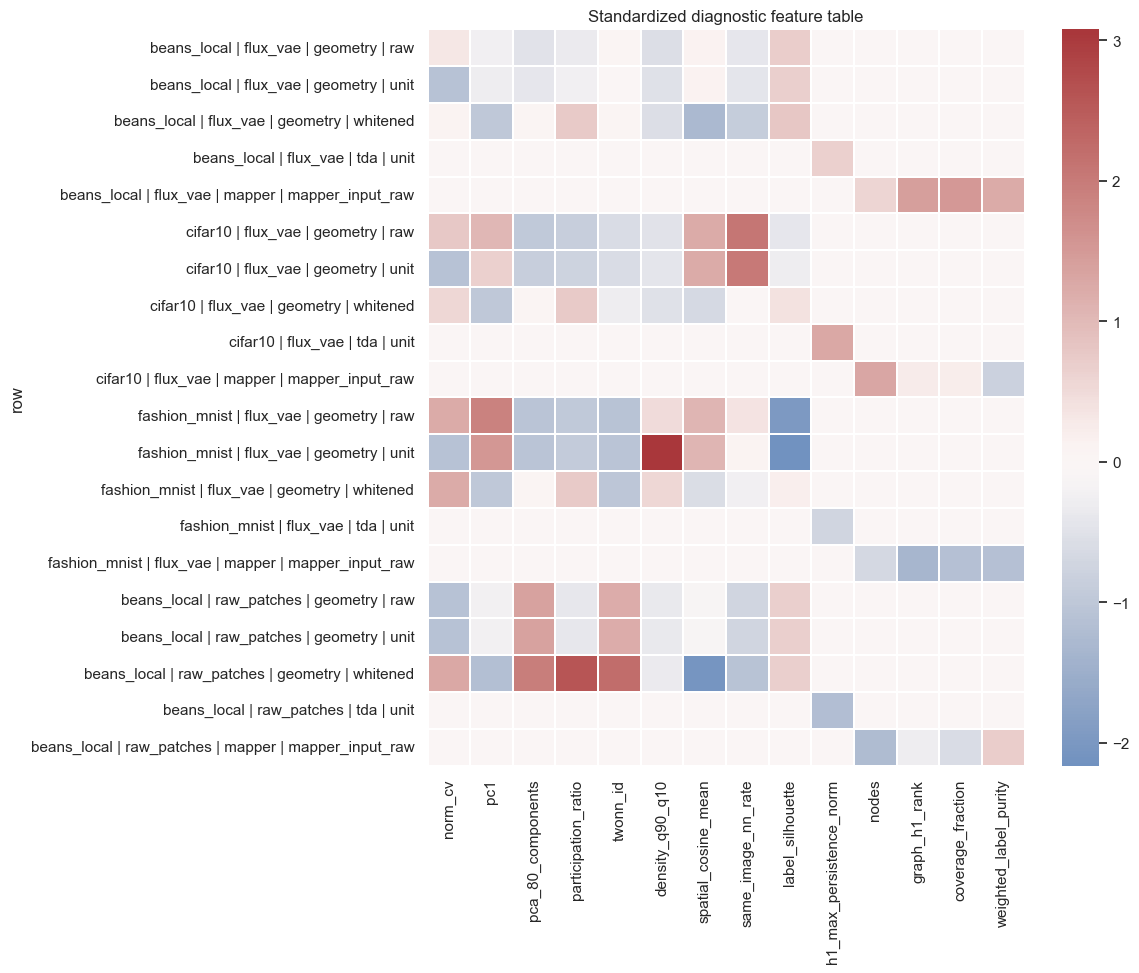

In [5]:
plot_feature_heatmap(feature_table)

## 4. Stable Mapper-Node Matching

Mapper node IDs are local to one run. The matching below asks a simpler
question: if we bootstrap overlapping samples from the same token pool,
does a reference node recover the same source tokens in other runs?

Target cloud: **beans_local**

,run_id,seed,lens,config,nodes,edges,components,graph_h1_rank,coverage_fraction,mean_memberships_per_covered_point,...,largest_component_fraction,weighted_label_purity,n_input_points,n_lens_dimensions,n_intervals,overlap,min_bin_points,clusterer,min_cluster_size,eps_quantile
0,seed72,72,norm_density,baseline,88,264,2,178,0.858,1.858,...,0.989,0.460,1650,2,8,0.35,12,dbscan,5,0.35
1,seed73,73,norm_density,baseline,92,269,2,179,0.868,1.860,...,0.989,0.482,1650,2,8,0.35,12,dbscan,5,0.35
2,seed74,74,norm_density,baseline,80,248,1,169,0.865,1.872,...,1.000,0.464,1650,2,8,0.35,12,dbscan,5,0.35


,reference_node_id,reference_size,recurrence,median_best_jaccard,max_best_jaccard,dominant_label,label_purity,label_purity_excess,dominant_image_fraction,spatial_radius
0,83,13,1.0,0.701,0.714,angular_leaf_spot,1.000,0.649,0.385,7.086
1,37,3,1.0,0.675,0.750,angular_leaf_spot,0.667,0.316,0.333,10.511
2,81,13,1.0,0.633,0.667,angular_leaf_spot,0.462,0.111,0.231,15.450
3,85,12,1.0,0.571,0.786,healthy,0.417,0.066,0.167,14.005
4,80,12,1.0,0.538,0.538,healthy,0.667,0.316,0.333,10.164
5,71,15,1.0,0.528,0.556,bean_rust,0.400,0.049,0.267,13.558
6,69,7,1.0,0.528,0.556,healthy,0.571,0.221,0.286,15.617
7,70,63,1.0,0.522,0.561,angular_leaf_spot,0.556,0.205,0.127,9.744
8,77,30,1.0,0.489,0.579,angular_leaf_spot,0.700,0.349,0.200,7.919
9,39,9,1.0,0.481,0.533,bean_rust,0.444,0.094,0.222,12.762


,run_a,run_b,node_a,node_b,size_a,size_b,intersection,jaccard,containment_a,containment_b
0,seed72,seed73,85,86,12,13,11,0.786,0.917,0.846
1,seed72,seed73,37,36,3,4,3,0.750,1.000,0.750
2,seed72,seed73,83,85,13,11,10,0.714,0.769,0.909
3,seed72,seed73,7,6,5,7,5,0.714,1.000,0.714
4,seed72,seed73,81,84,13,12,10,0.667,0.769,0.833
5,seed72,seed73,77,76,30,30,22,0.579,0.733,0.733
6,seed72,seed73,71,72,15,13,10,0.556,0.667,0.769
7,seed72,seed73,46,51,26,34,21,0.538,0.808,0.618
8,seed72,seed73,80,82,12,8,7,0.538,0.583,0.875
9,seed72,seed73,65,64,27,30,19,0.500,0.704,0.633


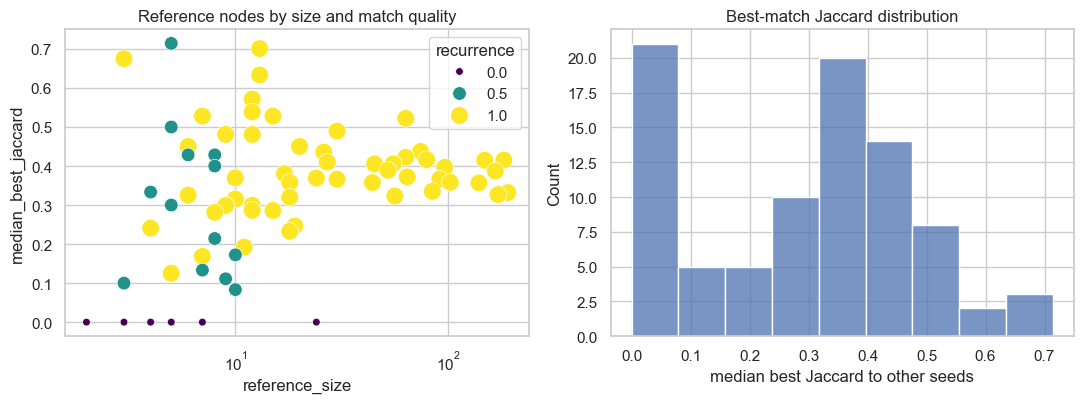

In [6]:
target_dataset = "beans_local" if "beans_local" in flux_clouds else sorted(flux_clouds)[0]
target_cloud = flux_clouds[target_dataset]

runs = build_mapper_stability_runs(
    target_cloud,
    seeds=STABILITY_SEEDS,
    lens_name="norm_density",
    config=mapper_config,
    pool_points=STABILITY_POOL_POINTS,
    sample_fraction=STABILITY_SAMPLE_FRACTION,
    pool_seed=SEED,
)
run_stats = summarize_stability_runs(runs)
display(Markdown(f"Target cloud: **{target_dataset}**"))
display(run_stats.round(3))

stability, matches = reference_node_stability(
    runs,
    reference_run=sorted(runs)[0],
    min_jaccard=0.05 if SMOKE else 0.08,
    matching="hungarian",
)
reference_run = sorted(runs)[0]
stability_summary = annotate_stability_with_node_summary(stability, runs[reference_run])

summary_cols = [
    "reference_node_id",
    "reference_size",
    "recurrence",
    "median_best_jaccard",
    "max_best_jaccard",
    "dominant_label",
    "label_purity",
    "label_purity_excess",
    "dominant_image_fraction",
    "spatial_radius",
]
summary_cols = [col for col in summary_cols if col in stability_summary.columns]
display(stability_summary[summary_cols].head(20).round(3))
display(matches.head(20).round(3) if not matches.empty else pd.DataFrame({"message": ["No node matches above threshold"]}))
plot_stability_overview(stability_summary)

## 5. Patch Atlas For Stable Nodes

This is the Activation-Atlas-inspired part, but kept honest: every cell
is a real approximate source patch attached to a stable Mapper node.

Selected nodes: 70, 77, 18, 44, 46, 33, 21, 35

,node_id,patch_rank,source_index,image_id,label,h,w
0,70,1,5689,5,healthy,17,25
1,70,2,9730,9,angular_leaf_spot,16,2
2,70,3,3155,3,angular_leaf_spot,2,19
3,70,4,30251,29,healthy,17,11
4,70,5,42992,41,healthy,31,16
5,70,6,20546,20,healthy,2,2
6,77,1,37145,36,angular_leaf_spot,8,25
7,77,2,422,0,angular_leaf_spot,13,6
8,77,3,16017,15,angular_leaf_spot,20,17
9,77,4,23220,22,bean_rust,21,20


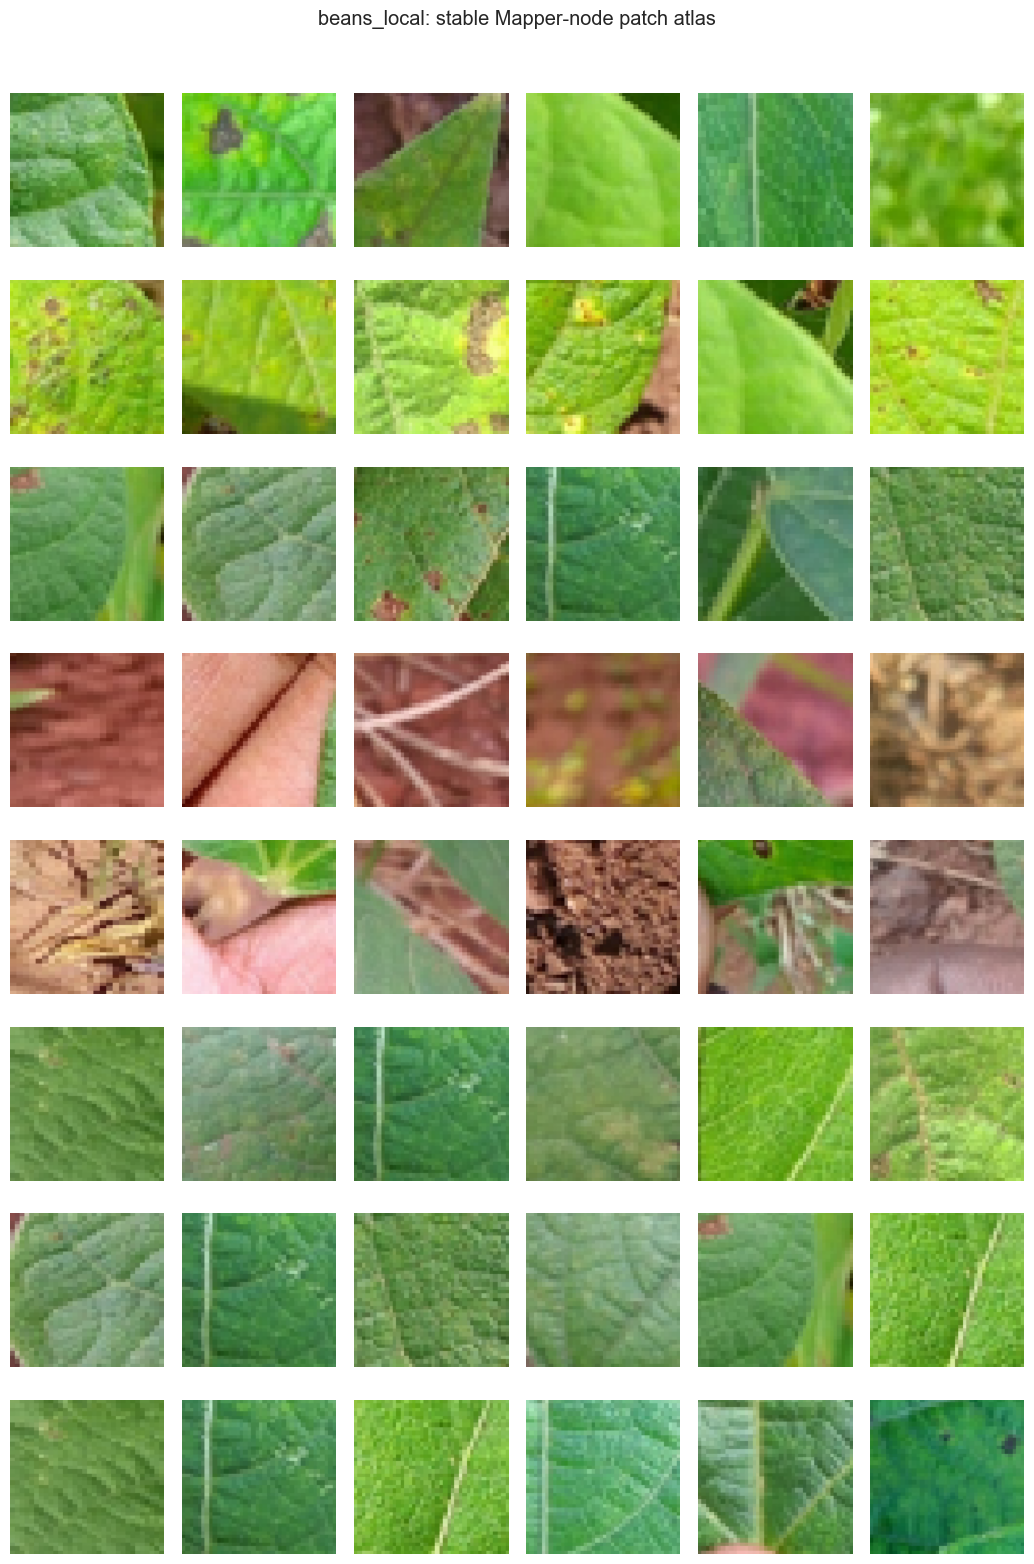

In [7]:
try:
    n_images = int(target_cloud.token_metadata["image_id"].max()) + 1
    images, image_metadata = load_project_images(n_images=n_images, image_dir=IMAGE_DIR)
    atlas_nodes = select_stable_atlas_nodes(
        stability_summary,
        max_nodes=4 if SMOKE else 8,
        min_recurrence=0.5,
        min_size=8 if SMOKE else 16,
    )
    display(Markdown("Selected nodes: " + ", ".join(str(node) for node in atlas_nodes)))
    atlas_records = patch_atlas_records(
        runs[reference_run].graph,
        target_cloud,
        atlas_nodes,
        patches_per_node=4 if SMOKE else 6,
    )
    display(atlas_records.head(40))
    plot_patch_atlas(
        runs[reference_run].graph,
        target_cloud,
        images,
        atlas_nodes,
        node_summary=stability_summary,
        patches_per_node=4 if SMOKE else 6,
        image_size=IMAGE_SIZE,
        title=f"{target_dataset}: stable Mapper-node patch atlas",
    )
except Exception as exc:
    display(Markdown(f"Patch atlas unavailable: `{type(exc).__name__}: {exc}`"))

## 6. Frozen Confirmatory Contract

The workbench above is exploratory. The config below is the draft
confirmatory target: stable, label-enriched Mapper node tracks versus
the strongest matched control.

In [8]:
config_path = ROOT / "experiment_configs" / "mapper_node_stability_v1.json"
prereg = json.loads(config_path.read_text())
display(
    pd.DataFrame(
        [
            {"field": "primary_question", "value": prereg["primary_question"]},
            {"field": "primary_statistic", "value": prereg["primary_statistic"]},
            {"field": "pass_rule", "value": "; ".join(prereg["decision_rule"]["pass"])},
            {"field": "fail_interpretation", "value": prereg["decision_rule"]["fail_interpretation"]},
        ]
    )
)

,field,value
0,primary_question,Do observed FLUX token clouds contain more sta...
1,primary_statistic,stable_enriched_track_count_delta = observed_c...
2,pass_rule,mean stable_enriched_track_count_delta across ...
3,fail_interpretation,A failure is evidence that the current Mapper ...


## Current Interpretation

Treat any stable node as a candidate regime, not as proof. The next
useful question is whether the stable nodes beat controls in count,
enrichment, and recurrence. If they do, Mapper gives us a compact local
diagnostic. If they do not, the feature table and patch atlas still tell
us where the representation varies and where Mapper is mostly drawing
the cover geometry.